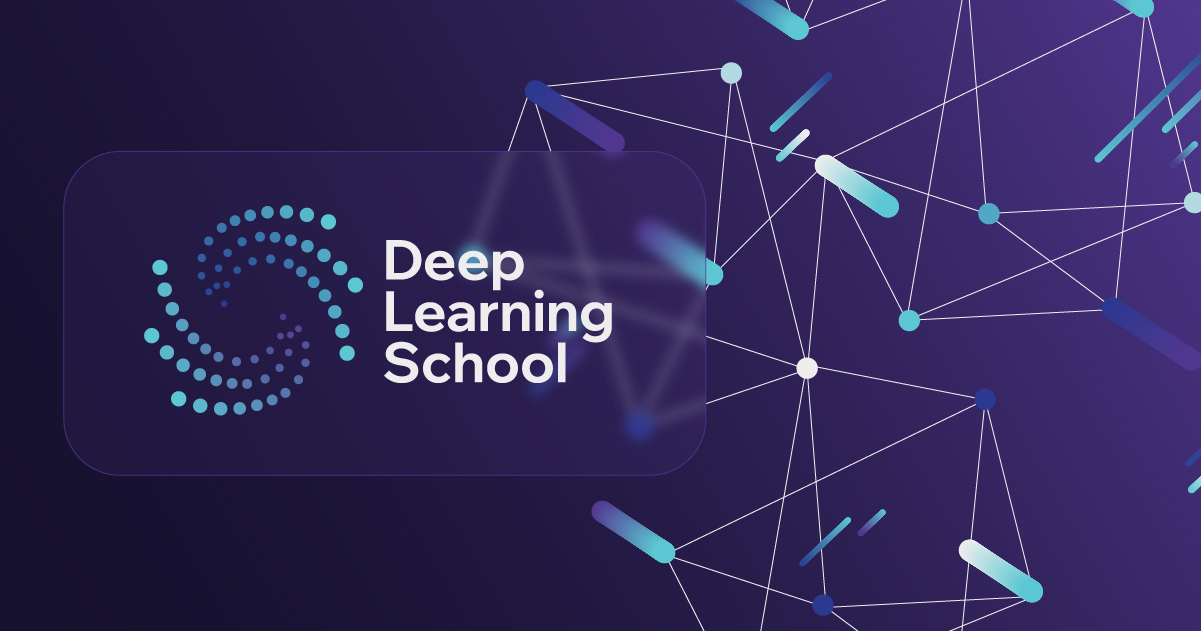


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.



# Загрузка данных


1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>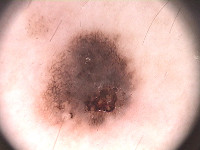</td><td>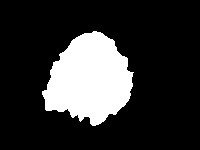</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

# get_ipython().system_raw("unrar x PH2Dataset.rar")


Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

#!pip install scikit-image


## для локальной загрузки

import os




## для kaggle

if 1:


Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


from skimage.transform import resize

import numpy as np


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

import matplotlib.pyplot as plt


Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

ix = np.random.choice(len(X), len(X), False)

print(len(tr), len(val), len(ts))


## PyTorch DataLoader

from torch.utils.data import DataLoader

import torch


# Метрика


## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.



Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:




<p style="align: center;"><img align=center src="https://drive.usercontent.google.com/download?id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN&export=view&authuser=0" width=1000 height=800/></p>

# !pip install torchmetrics

from torchmetrics import JaccardIndex


# Построй свой первый бейзлайн!


Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]


## BCE Loss [2 балла]


Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$


### Вывод численно стабильной формулы BCE лосса [1 балл]




Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.


**Вывод формулы:**


Исходная формула BCE для одного элемента:
$$
\mathcal{L}_{BCE}(y, \hat{y}) = -y \log(\sigma(\hat{y})) - (1-y)\log(1-\sigma(\hat{y}))
$$

Где $\sigma(\hat{y}) = \frac{1}{1 + e^{-\hat{y}}}$



Подставляем  $\sigma(\hat{y})$
$$
\log(\sigma(\hat{y})) = \log\left(\frac{1}{1+e^{-\hat{y}}}\right) = -\log(1 + e^{-\hat{y}})
$$




Подставим в $\log(1-\sigma(\hat{y}))$ значение $\sigma(\hat{y})$
$$
1 - \sigma(\hat{y}) = \frac{e^{-\hat{y}}}{1 + e^{-\hat{y}}}
$$
$$
\log(1-\sigma(\hat{y})) = \log\left(\frac{e^{-\hat{y}}}{1+e^{-\hat{y}}}\right) = -\hat{y} - \log(1 + e^{-\hat{y}})
$$




По исходной формуле
$$
\mathcal{L}_{BCE} = -y[-\log(1 + e^{-\hat{y}})] - (1-y)[-\hat{y} - \log(1 + e^{-\hat{y}})]
$$

$$
= y\log(1 + e^{-\hat{y}}) + (1-y)\hat{y} + (1-y)\log(1 + e^{-\hat{y}})
$$



Вынесем за скобки $\log(1 + e^{-\hat{y}})$

$$
= [y + (1-y)]\log(1 + e^{-\hat{y}}) + (1-y)\hat{y}
$$
$$
= \log(1 + e^{-\hat{y}}) + \hat{y} - y\hat{y}
$$




---





$$
\mathcal{L}_{BCE} = \hat{y} - y\hat{y} + \log(1 + e^{-\hat{y}})
$$




### Реализуйте в коде оба варианта лосса [1 балл]


Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

import torch.nn as nn

bce_torch = nn.BCELoss(reduction='sum')  # (sigmoid(y_pred), y_real)

def bce_true(y_hat, y):

def bce_loss(y_hat, y):


Проверим корректность работы на простом примере

def iou_pytorch(outputs, labels):

y_pred = torch.randn(3, 2, requires_grad=False)

bce_Logits(y_pred, y_true).mean()




Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))


Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)

assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))


Давайте посчитаем на реальных логитах и сегментационной маске:

# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

# path_to_dummy_samples = '..\\..\\for_asserts'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3 * 10))


Проверяем на данном примере:

bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())


### доп. лоссы для экспериментов


def bce_Logits(y_pred, y_true):

def BCE_stabilized(y_pred, y_true):


## SegNet [2 балла]


Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

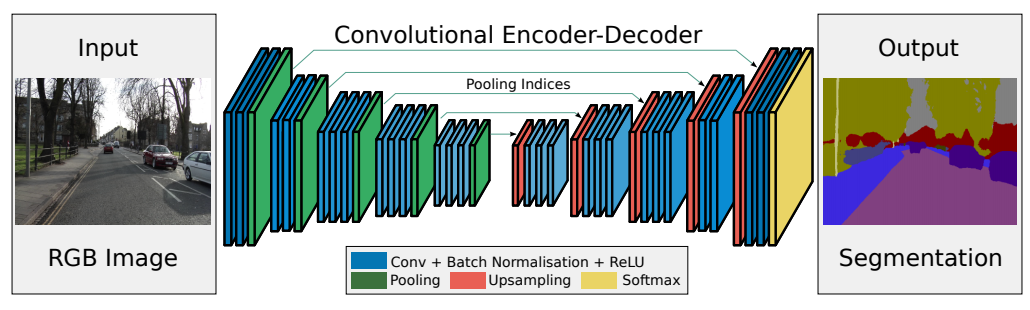

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)


Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

import torch


Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239



рассмотрим сверточную сеть VGG16  для создания кодера нашей реализации SegNet

from torchvision import models


Архитектуру Segnet необходимо реализовать для нашей задачи: 256х256 и 2 класа

class SegNet(nn.Module):


## Тренировка [1 балл]

Напишите функцию для обучения модели.

from IPython.display import clear_output

def train(model, opt, loss_fn, epochs, data_tr, data_val, sched=None, freq=1):

from seaborn import lineplot


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

import gc

model = SegNet().to(device)


## Сохранение модели

# torch.save(model, 'SegNet_model.pth')


Модель доступна здесь https://disk.yandex.ru/d/1hDArlOxyVhmmw

visualize_and_save(history_bce, 'history_bce')


> в начале обучения потери очень неустойчивы, вероятно что модель должна подобрать первоначальную маску. В конце обучения проверка метрики сильно меняется вероятно из-за малого количества картинок


## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

def predict(model, data):

def score_model(model, metric, data):

Y_pred = predict(model, X[ts])

round(score_model(model, iou_pytorch, test_dataloader),3)


> протестировал модель на тестовой выборке (score = 0.826). Также сделана выборочная проверка по картинкам и маске.


# Мир других лоссов!


## Дополнительные функции потерь [2 балла]


В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.



### Dice Loss


**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE


Итак, давайте сначала пропишем dice_score.

def dice_score(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:


Проверим на корректность функцию dice_score:

d1 = dice_score(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'])

from torchmetrics.segmentation import DiceScore

dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels']) == dice_score(dummpy_sample['logits'].sigmoid(),


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

# !pip install monai

def dice_loss(logits: torch.Tensor, labels: torch.Tensor, smooth: float = 1e-6) -> torch.Tensor:


Проверка на корректность:

from monai.losses import DiceLoss

dice_loss(dummpy_sample['logits'], dummpy_sample['labels'], smooth=0).item()

dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels']).item()

assert (dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) ==


> Функция потерь Dice реализована правильно


### Focal Loss


[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.



Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

import torch.nn.functional as F


Проверка корректности функции:

from torchvision.ops import sigmoid_focal_loss

focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2,


> Функция потерь Focal реализована правильно


## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)




## Обучите SegNet на новых лоссах


**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.




### Использование Dice

model_dice = SegNet().to(device)

visualize_and_save(history_dice, 'history_dice')

round(score_model(model_dice, iou_pytorch, valid_dataloader),3)


### Использование Focal

model_focal = SegNet().to(device)

visualize_and_save(history_focal, 'history_dice')

round(score_model(model_focal, iou_pytorch, valid_dataloader),3)


> Модель сходится лучше при применении функции Focal


# Новая модель!


## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

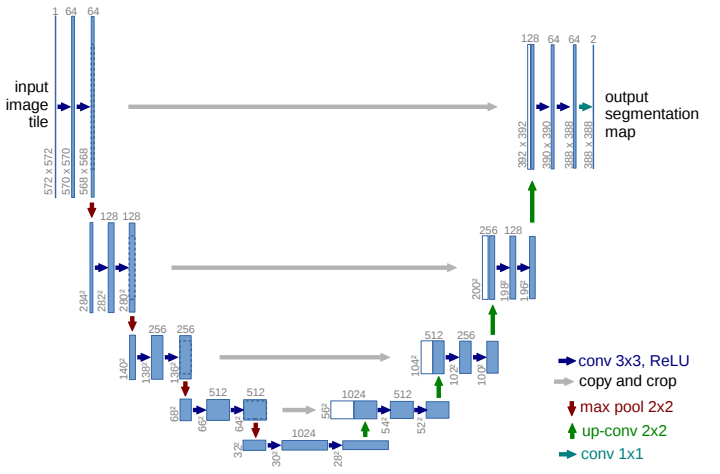


У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.



class UNet(nn.Module):


## Обучите UNet 2
Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



### Обучение UNet на BCE

import gc

import torch.optim as optim

unet_model = UNet().to(device)

visualize_and_save(history_unet, 'history_unet')

score_model(unet_model, iou_pytorch, valid_dataloader)


### Обучение UNet на Dice




import gc

unet_model = UNet().to(device)

visualize_and_save(history_unet, 'history_unet_dice')

score_model(unet_model, iou_pytorch, valid_dataloader)


### Обучение UNet на Focal

import gc

unet_model = UNet().to(device)

visualize_and_save(history_unet, 'history_unet_focal')

score_model(unet_model, iou_pytorch, valid_dataloader)


Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.


**Вывод**
> Провел обучение по всем лоссам




